In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


##base = r"C:\Users\Sofia Luis\Documents\SYS 3060\Stochastic-Decision-Modeling-Project"

##results_df = pd.read_csv(os.path.join(base, "outputs", "sensitivity_tests", "summary_results.csv"))


results_df = pd.read_csv("../outputs/sensitivity_tests/summary_results.csv")

baseline = results_df[
    (results_df.tmax==83) &
    (results_df.tmin==54) &
    (results_df.precip==13)
].iloc[0]

results_df["delta_full_acc"] = results_df["full_acc"] - baseline["full_acc"]
results_df["delta_log_likel"] = results_df["full_loglik"] - baseline["full_loglik"]

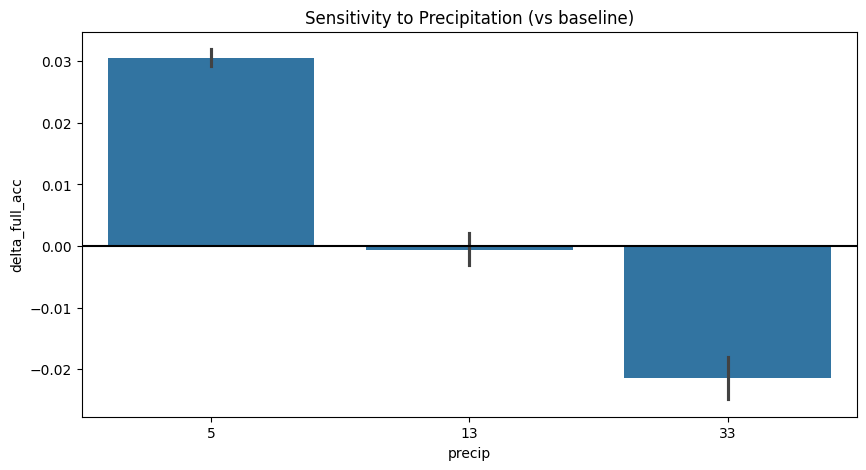

In [38]:
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="precip", y="delta_full_acc")
plt.axhline(0, color="black")
plt.title("Sensitivity to Precipitation (vs baseline)")
plt.show()

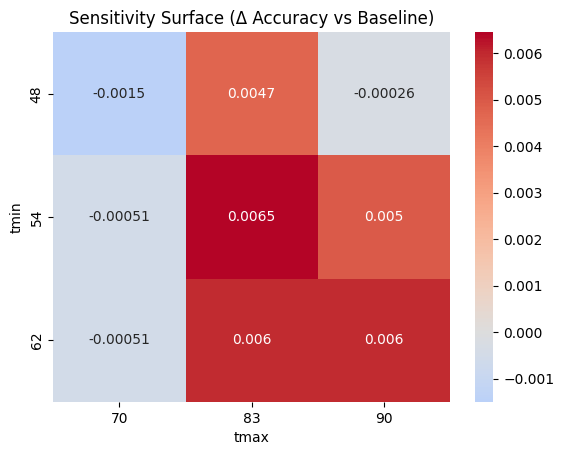

In [39]:
pivot = results_df.pivot_table(
    index="tmin",
    columns="tmax",
    values="delta_full_acc"
)

sns.heatmap(pivot, annot=True, cmap="coolwarm", center=0)
plt.title("Sensitivity Surface (Δ Accuracy vs Baseline)")
plt.show()

In [40]:
best_row = results_df.loc[results_df["delta_full_acc"].idxmax()]
print(best_row[['tmax','tmin','precip','delta_full_acc']])

tmax              83.000000
tmin              48.000000
precip             5.000000
delta_full_acc     0.033953
Name: 9, dtype: float64


In [41]:
best_log = results_df.loc[results_df["delta_log_likel"].idxmax()]
print(best_log[['tmax','tmin','precip','delta_log_likel']])

tmax               70.000000
tmin               62.000000
precip              5.000000
delta_log_likel     0.078081
Name: 6, dtype: float64


In [42]:
best_long_term = results_df.loc[results_df["full_acc_14"].idxmax()]
print(best_long_term[['tmax','tmin','precip','full_acc_14']])

tmax           70.000000
tmin           48.000000
precip          5.000000
full_acc_14     0.653251
Name: 0, dtype: float64
